In [1]:
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import linear_kernel, cosine_similarity
from nltk.stem.snowball import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import wordnet

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("../data/tmdb_movie_data.csv", low_memory=False)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15711 entries, 0 to 15710
Data columns (total 34 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   adult                                15711 non-null  bool   
 1   backdrop_path                        15613 non-null  str    
 2   budget                               15711 non-null  int64  
 3   genres                               15711 non-null  str    
 4   homepage                             4953 non-null   str    
 5   id                                   15711 non-null  int64  
 6   imdb_id                              15710 non-null  str    
 7   origin_country                       15711 non-null  str    
 8   original_language                    15711 non-null  str    
 9   original_title                       15711 non-null  str    
 10  overview                             15711 non-null  str    
 11  popularity                           15

## Data Parsing
- Data Parsing
- Export Selected Feature

In [4]:
def parse_json(json_str: str):
    """
    Parse a JSON string and return a list of values.
    If the input is not a valid JSON string, return an empty list.
    """
    try:
        # Use ast.literal_eval to safely evaluate the string as a Python literal
        import ast

        parsed_list = ast.literal_eval(json_str)
        # Extract the 'name' field from each dictionary in the list
        return [
            item["name"]
            for item in parsed_list
            if isinstance(item, dict) and "name" in item
        ]
    except (ValueError, SyntaxError):
        return []


def parse_json_object(json_str: str):
    """
    Parse a JSON string and return a list of values.
    If the input is not a valid JSON string, return an empty list.
    """
    try:
        # Use ast.literal_eval to safely evaluate the string as a Python literal
        import ast

        parsed_object = ast.literal_eval(json_str)
        return parsed_object
    except (ValueError, SyntaxError):
        return []

| idx | name | count | nullity | type | included | preprocessing |
| -------- | ------- | -------- | ------- | -------- | ------- | -------- |
| 0 |   adult                               | 15711 | non-null |  bool    | X |
| 1 |   backdrop_path                       | 15613 | non-null |  str     | X |
| 2 |   budget                              | 15711 | non-null |  int64   | / | 
| 3 |   genres                              | 15711 | non-null |  str     | / | multihot encoding
| 4 |   homepage                            | 4953 | non-null |   str     | x |
| 5 |   id                                  | 15711 | non-null |  int64   | X |
| 6 |   imdb_id                             | 15710 | non-null |  str     | X |
| 7 |   origin_country                      | 15711 | non-null |  str     | X |
| 8 |   original_language                   | 15711 | non-null |  str     | X | 
| 9 |   original_title                      | 15711 | non-null |  str     | X |
| 10 |  overview                            | 15711 | non-null |  str     | / | embedding
| 11 |  popularity                          | 15711 | non-null |  float64 | / |
| 12 |  poster_path                         | 15707 | non-null |  str     | X |
| 13 |  production_companies                | 15711 | non-null |  str     | / | split into 2 - 3 slots
| 14 |  production_countries                | 15711 | non-null |  str     | X |
| 15 |  release_date                        | 15711 | non-null |  str     | / | date numerize
| 16 |  revenue                             | 15711 | non-null |  int64   | / |
| 17 |  runtime                             | 15711 | non-null |  int64   | / |
| 18 |  softcore                            | 15711 | non-null |  bool    | X |
| 19 |  spoken_languages                    | 15711 | non-null |  str     | X |
| 20 |  status                              | 15711 | non-null |  str     | X | 
| 21 |  tagline                             | 13181 | non-null |  str     | / | embedding
| 22 |  title                               | 15711 | non-null |  str     | X |
| 23 |  video                               | 15711 | non-null |  bool    | X |
| 24 |  vote_average                        | 15711 | non-null |  float64 | X |
| 25 |  vote_count                          | 15711 | non-null |  int64   | X |
| 26 |  belongs_to_collection.id            | 2959 | non-null |   float64 | X |
| 27 |  belongs_to_collection.name          | 2959 | non-null |   str     | X |
| 28 |  belongs_to_collection.poster_path   | 2880 | non-null |   str     | X |
| 29 |  belongs_to_collection.backdrop_path | 2682 | non-null |   str     | X |
| 30 |  credits.cast                        | 15711 | non-null |  str     | / | top 5
| 31 |  credits.crew                        | 15711 | non-null |  str     | / | key roles: director, writor, exec producer
| 32 |  keywords.keywords                   | 15711 | non-null |  str     | / | ?
| 33 |  belongs_to_collection               | 0 | non-null |      float64 | X |

In [5]:
drop_columns = [
    "adult",
    "backdrop_path",
    "homepage",
    "id",
    "imdb_id",
    "origin_country",
    "original_language",
    "original_title",
    "poster_path",
    "softcore",
    "spoken_languages",
    "status",
    "video",
    "popularity",
    "production_countries",
    "belongs_to_collection.id",
    "belongs_to_collection.name",
    "belongs_to_collection.poster_path",
    "belongs_to_collection.backdrop_path",
    "belongs_to_collection",
]
preprocessed_columns = set()

In [6]:
if drop_columns[0] in df.columns:
    df.drop(columns=drop_columns, inplace=True)

In [7]:
df.head()

,budget,genres,overview,production_companies,release_date,revenue,runtime,tagline,title,vote_average,vote_count,credits.cast,credits.crew,keywords.keywords
0,30000000,"[{'id': 10751, 'name': 'Family'}, {'id': 35, '...","Led by Woody, Andy's toys live happily in his ...","[{'id': 3, 'logo_path': '/1TjvGVDMYsj6JBxOAkUH...",1995-11-22,401157969,81,The adventure takes off when toys come to life!,Toy Story,7.978,20023,"[{'adult': False, 'gender': 2, 'id': 31, 'know...","[{'adult': False, 'gender': 2, 'id': 12893, 'k...","[{'id': 10084, 'name': 'rescue'}, {'id': 6054,..."
1,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",When siblings Judy and Peter discover an encha...,"[{'id': 559, 'logo_path': '/eC0bWHVjnjUducyA6Y...",1995-12-15,262821940,104,It's a jungle in here.,Jumanji,7.247,11354,"[{'adult': False, 'gender': 2, 'id': 2157, 'kn...","[{'adult': False, 'gender': 2, 'id': 56521, 'k...","[{'id': 818, 'name': 'based on novel or book'}..."
2,25000000,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",A family wedding reignites the ancient feud be...,"[{'id': 19464, 'logo_path': None, 'name': 'Lan...",1995-12-22,71518503,101,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,6.478,431,"[{'adult': False, 'gender': 2, 'id': 6837, 'kn...","[{'adult': False, 'gender': 2, 'id': 26502, 'k...","[{'id': 1495, 'name': 'fishing'}, {'id': 9663,..."
3,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...","Cheated on, mistreated and stepped on, the wom...","[{'id': 25, 'logo_path': '/qZCc1lty5FzX30aOCVR...",1995-12-22,81452156,127,Friends are the people who let you be yourself...,Waiting to Exhale,6.243,206,"[{'adult': False, 'gender': 1, 'id': 8851, 'kn...","[{'adult': False, 'gender': 2, 'id': 2178, 'kn...","[{'id': 818, 'name': 'based on novel or book'}..."
4,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10751, '...",Just when George Banks has recovered from his ...,"[{'id': 9195, 'logo_path': '/geK5QOBsXIPGHutKw...",1995-12-08,76594107,106,Just when his world is back to normal... he's ...,Father of the Bride Part II,6.273,812,"[{'adult': False, 'gender': 2, 'id': 67773, 'k...","[{'adult': False, 'gender': 2, 'id': 37, 'know...","[{'id': 5600, 'name': 'daughter'}, {'id': 1009..."


In [8]:
# Idea
# # Budget pre-processing
# # Some budget is unknown, represented as 0 (6656 Movies)
# print(f"Number of movies with unknown budget: {len(df[df.budget == 0])}")
# # Budget is encoded in budget ranges with discretization
# #   budget_unknown (if 0)
# #   budget_low (under $5M)
# #   budget_medium ($5M - $40M)
# #   budget_high ($40M - $100M)
# #   budget_blockbuster (over $100M)
# # df["budget_range"] =
# pd.get_dummies(pd.cut(
#     df["budget"],
#     bins=[-1, 0, 5_000_000, 40_000_000, 100_000_000, float("inf")],
#     labels=[
#         "budget_unknown",
#         "budget_low",
#         "budget_medium",
#         "budget_high",
#         "budget_blockbuster",
#     ],
# ))

In [9]:
# Preprocess the 'genres' column
df["genres"] = df["genres"].apply(parse_json)
df.head()

,budget,genres,overview,production_companies,release_date,revenue,runtime,tagline,title,vote_average,vote_count,credits.cast,credits.crew,keywords.keywords
0,30000000,"[Family, Comedy, Animation, Adventure]","Led by Woody, Andy's toys live happily in his ...","[{'id': 3, 'logo_path': '/1TjvGVDMYsj6JBxOAkUH...",1995-11-22,401157969,81,The adventure takes off when toys come to life!,Toy Story,7.978,20023,"[{'adult': False, 'gender': 2, 'id': 31, 'know...","[{'adult': False, 'gender': 2, 'id': 12893, 'k...","[{'id': 10084, 'name': 'rescue'}, {'id': 6054,..."
1,65000000,"[Adventure, Fantasy, Family]",When siblings Judy and Peter discover an encha...,"[{'id': 559, 'logo_path': '/eC0bWHVjnjUducyA6Y...",1995-12-15,262821940,104,It's a jungle in here.,Jumanji,7.247,11354,"[{'adult': False, 'gender': 2, 'id': 2157, 'kn...","[{'adult': False, 'gender': 2, 'id': 56521, 'k...","[{'id': 818, 'name': 'based on novel or book'}..."
2,25000000,"[Romance, Comedy]",A family wedding reignites the ancient feud be...,"[{'id': 19464, 'logo_path': None, 'name': 'Lan...",1995-12-22,71518503,101,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,6.478,431,"[{'adult': False, 'gender': 2, 'id': 6837, 'kn...","[{'adult': False, 'gender': 2, 'id': 26502, 'k...","[{'id': 1495, 'name': 'fishing'}, {'id': 9663,..."
3,16000000,"[Comedy, Drama, Romance]","Cheated on, mistreated and stepped on, the wom...","[{'id': 25, 'logo_path': '/qZCc1lty5FzX30aOCVR...",1995-12-22,81452156,127,Friends are the people who let you be yourself...,Waiting to Exhale,6.243,206,"[{'adult': False, 'gender': 1, 'id': 8851, 'kn...","[{'adult': False, 'gender': 2, 'id': 2178, 'kn...","[{'id': 818, 'name': 'based on novel or book'}..."
4,0,"[Comedy, Family]",Just when George Banks has recovered from his ...,"[{'id': 9195, 'logo_path': '/geK5QOBsXIPGHutKw...",1995-12-08,76594107,106,Just when his world is back to normal... he's ...,Father of the Bride Part II,6.273,812,"[{'adult': False, 'gender': 2, 'id': 67773, 'k...","[{'adult': False, 'gender': 2, 'id': 37, 'know...","[{'id': 5600, 'name': 'daughter'}, {'id': 1009..."


In [10]:
# multihot encoding for genres
# from sklearn.preprocessing import MultiLabelBinarizer

# mlb = MultiLabelBinarizer()
# genres_multihot = mlb.fit_transform(df["genres"])

# # save the multihot encoded genres to a new DataFrame
# genres_df = pd.DataFrame(genres_multihot, columns=mlb.classes_)
# genres_df.head()
# concat_df = pd.concat([df, genres_df], axis=1)
# preprocessed_columns.update(["genres"])

In [11]:
vote_counts = df[df['vote_count'].notnull()]['vote_count'].astype('int')
vote_averages = df[df['vote_average'].notnull()]['vote_average'].astype('float')
C = vote_averages.mean()
C

np.float64(6.520433008720006)

In [12]:
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').apply(lambda x: str(x).split('-')[0] if x != np.nan else np.nan)
preprocessed_columns.update(["release_date"])

In [13]:
m = 50 # Minimum number of votes required to be listed in the chart, 50 is a good threshold for our dataset

def weighted_rating(x):
    v = x['vote_count']
    R = x['vote_average']
    return (v/(v+m) * R) + (m/(m+v) * C)

In [14]:
df['weighted_rating'] = df.apply(weighted_rating, axis=1)
preprocessed_columns.update(["vote_count", "vote_average"])
df.head()

,budget,genres,overview,production_companies,release_date,revenue,runtime,tagline,title,vote_average,vote_count,credits.cast,credits.crew,keywords.keywords,year,weighted_rating
0,30000000,"[Family, Comedy, Animation, Adventure]","Led by Woody, Andy's toys live happily in his ...","[{'id': 3, 'logo_path': '/1TjvGVDMYsj6JBxOAkUH...",1995-11-22,401157969,81,The adventure takes off when toys come to life!,Toy Story,7.978,20023,"[{'adult': False, 'gender': 2, 'id': 31, 'know...","[{'adult': False, 'gender': 2, 'id': 12893, 'k...","[{'id': 10084, 'name': 'rescue'}, {'id': 6054,...",1995,7.974369
1,65000000,"[Adventure, Fantasy, Family]",When siblings Judy and Peter discover an encha...,"[{'id': 559, 'logo_path': '/eC0bWHVjnjUducyA6Y...",1995-12-15,262821940,104,It's a jungle in here.,Jumanji,7.247,11354,"[{'adult': False, 'gender': 2, 'id': 2157, 'kn...","[{'adult': False, 'gender': 2, 'id': 56521, 'k...","[{'id': 818, 'name': 'based on novel or book'}...",1995,7.243814
2,25000000,"[Romance, Comedy]",A family wedding reignites the ancient feud be...,"[{'id': 19464, 'logo_path': None, 'name': 'Lan...",1995-12-22,71518503,101,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,6.478,431,"[{'adult': False, 'gender': 2, 'id': 6837, 'kn...","[{'adult': False, 'gender': 2, 'id': 26502, 'k...","[{'id': 1495, 'name': 'fishing'}, {'id': 9663,...",1995,6.482411
3,16000000,"[Comedy, Drama, Romance]","Cheated on, mistreated and stepped on, the wom...","[{'id': 25, 'logo_path': '/qZCc1lty5FzX30aOCVR...",1995-12-22,81452156,127,Friends are the people who let you be yourself...,Waiting to Exhale,6.243,206,"[{'adult': False, 'gender': 1, 'id': 8851, 'kn...","[{'adult': False, 'gender': 2, 'id': 2178, 'kn...","[{'id': 818, 'name': 'based on novel or book'}...",1995,6.297186
4,0,"[Comedy, Family]",Just when George Banks has recovered from his ...,"[{'id': 9195, 'logo_path': '/geK5QOBsXIPGHutKw...",1995-12-08,76594107,106,Just when his world is back to normal... he's ...,Father of the Bride Part II,6.273,812,"[{'adult': False, 'gender': 2, 'id': 67773, 'k...","[{'adult': False, 'gender': 2, 'id': 37, 'know...","[{'id': 5600, 'name': 'daughter'}, {'id': 1009...",1995,6.287352


In [15]:
df['tagline'] = df['tagline'].fillna('')
df['description'] = df['overview'] + df['tagline']
df['description'] = df['description'].fillna('')
preprocessed_columns.update(["overview", "tagline"])

In [16]:
# Preprocess the 'keywords' column
df["keywords"] = (
    df["keywords.keywords"]
    .apply(parse_json)
    .apply(lambda x: [item.lower() for item in x if isinstance(item, str)])
)
df["keywords"].head()
preprocessed_columns.update(["keywords.keywords"])

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import WordNetLemmatizer
import nltk
import re

nltk.download("wordnet")
nltk.download("punkt")
nltk.download("punkt_tab")

lemmatizer = WordNetLemmatizer()

# A small helper to completely sanitize individual items before joining them
def sanitize_item(item):
    if not isinstance(item, str):
        return ""
    # 1. Strip leading/trailing whitespaces and lower it
    item = item.strip().lower()
    # 2. Replace any internal spaces or hyphens with underscores
    item = item.replace(" ", "_").replace("-", "_")
    # 3. Strip any accidental leading/trailing underscores
    item = item.strip("_")
    # 4. Filter out items that are pure punctuation (e.g., "&", ".", ")")
    if not re.search(r'[a-zA-Z0-9]', item):
        return ""
    return item


def custom_preprocessor(text):
    text = text.lower()
    
    # 1. Standardize punctuation and handle the stray underscores
    text = re.sub(r'[()&.,–]', ' ', text)  # Drop raw punctuation symbols
    text = re.sub(r'\b_+|_+\b', '', text)  # Strip leading/trailing underscores from tokens
    
    # 2. Unify explicit acronyms/synonyms
    synonym_map = {
        "a.i": "artificial_intelligence",
        "u.s.": "united_states",
        "u.s.a": "united_states",
        "cia": "central_intelligence_agency",
        "mcu": "marvel_cinematic_universe",
        "ptsd": "post_traumatic_stress_disorder",
        "satirical": "satire",
        "surreal": "surrealism",
        "tragic": "tragedy",
        "romantic": "romance"
    }
    
    # Replace the words if found as standalone tokens
    words = text.split()
    cleaned_words = [synonym_map.get(w, w) for w in words]
    
    return " ".join(cleaned_words)


def custom_tokenizer(text):
    # Tokenize and lemmatize words to remove plurals/tenses
    tokens = nltk.word_tokenize(text)
    vocab =  [lemmatizer.lemmatize(token) for token in tokens]
    final_clean_vocab = [token for token in vocab if len(token) > 1]
    return final_clean_vocab


# keywords_vectorizer = TfidfVectorizer(
#     max_features=1000,
#     stop_words="english",
#     preprocessor=custom_preprocessor,
#     tokenizer=custom_tokenizer,
# )
# # Fit and transform the keywords column
# keywords_tfidf = keywords_vectorizer.fit_transform(
#     df["keywords"].apply(lambda x: " ".join([sanitize_item(item) for item in x if sanitize_item(item)]))
# )
# # Convert the TF-IDF matrix to a DataFrame
# keywords_df = pd.DataFrame(
#     keywords_tfidf.toarray(), columns=keywords_vectorizer.get_feature_names_out()
# )
# keywords_df.head()

[nltk_data] Downloading package wordnet to /Users/nut/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /Users/nut/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/nut/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [18]:
# list(keywords_df.columns)

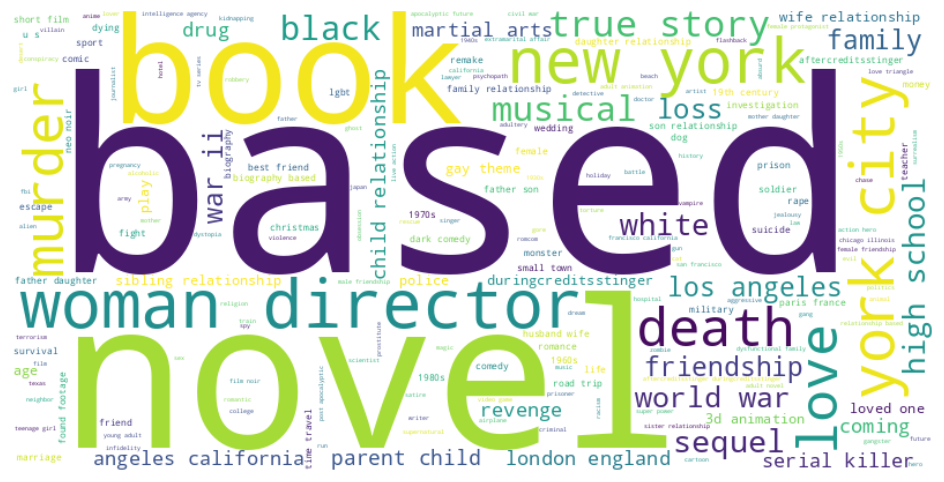

In [19]:
from wordcloud import WordCloud

import matplotlib.pyplot as plt

text = " ".join(df["keywords"].explode().dropna().astype(str).tolist())

wc = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [20]:
# Preprocess crew
crew = df['credits.crew'].apply(parse_json_object)
df['crew'] = crew
# df['crew_size'] = crew.apply(lambda x: len(x) if isinstance(x, list) else 0)
preprocessed_columns.update(["credits.crew"])
crew.head()

0    [{'adult': False, 'gender': 2, 'id': 12893, 'k...
1    [{'adult': False, 'gender': 2, 'id': 56521, 'k...
2    [{'adult': False, 'gender': 2, 'id': 26502, 'k...
3    [{'adult': False, 'gender': 2, 'id': 2178, 'kn...
4    [{'adult': False, 'gender': 2, 'id': 37, 'know...
Name: credits.crew, dtype: object

In [21]:
crew[0]

[{'adult': False,
  'gender': 2,
  'id': 12893,
  'known_for_department': 'Writing',
  'name': 'Alec Sokolow',
  'original_name': 'Alec Sokolow',
  'popularity': 0.5593,
  'profile_path': '/8E33sB5x2XGtjde9ubs78hEhFe8.jpg',
  'credit_id': '52fe4284c3a36847f8024f61',
  'department': 'Writing',
  'job': 'Screenplay'},
 {'adult': False,
  'gender': 2,
  'id': 12895,
  'known_for_department': 'Production',
  'name': 'Edwin Catmull',
  'original_name': 'Edwin Catmull',
  'popularity': 0.2368,
  'profile_path': '/dRxY51eWnvSpTn1A2MQOwbnHDFE.jpg',
  'credit_id': '52fe4284c3a36847f8024f6d',
  'department': 'Production',
  'job': 'Executive Producer'},
 {'adult': False,
  'gender': 2,
  'id': 12896,
  'known_for_department': 'Production',
  'name': 'Ralph Guggenheim',
  'original_name': 'Ralph Guggenheim',
  'popularity': 0.1349,
  'profile_path': '/3XhuBjcdE9hRZGQ4GyJ6h0mObig.jpg',
  'credit_id': '52fe4284c3a36847f8024f73',
  'department': 'Production',
  'job': 'Producer'},
 {'adult': False,


In [22]:
from collections import Counter

def parse_crew_job(crew_list):
    """
    Parse the crew list and return a dictionary with job titles as keys and names as values.
    If the input is not a valid list, return an empty dictionary.
    """
    if not isinstance(crew_list, list):
        return {}
    
    job_dict = {}
    for member in crew_list:
        if isinstance(member, dict) and "job" in member and "name" in member:
            job_dict[member["job"]] = member["name"]
    
    return job_dict
job_counter = Counter()
for crew_list in crew:
    if isinstance(crew_list, list):
        for member in crew_list:
            if isinstance(member, dict) and "job" in member:
                job_counter[member["job"]] += 1

job_counts_df = pd.DataFrame(job_counter.most_common(), columns=["job", "count"])
job_counts_df.sort_values("count", ascending=False).reset_index(drop=True).head(50).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
job,Stunts,Producer,Executive Producer,Editor,Director,Director of Photography,Makeup Artist,Casting,Original Music Composer,Art Direction,Screenplay,Production Design,Sound Re-Recording Mixer,Costume Design,Animation,Set Decoration,Writer,Hairstylist,Stunt Double,Stunt Coordinator,Co-Producer,Visual Effects Supervisor,Camera Operator,Sound Effects Editor,Associate Producer,Script Supervisor,Second Assistant Director,First Assistant Director,Set Dresser,Electrician,Still Photographer,Grip,Assistant Editor,Supervising Sound Editor,Gaffer,Sound Editor,Key Animation,Foley Artist,Visual Effects Producer,Production Assistant,Dialogue Editor,Boom Operator,Property Master,Music Editor,Production Manager,Thanks,Assistant Director,Sound Mixer,Production Coordinator,Set Designer
count,56698,35587,31141,19099,17080,15814,15771,15413,15374,14734,14586,12147,11599,11592,11464,10885,10839,8968,8471,8455,8130,8115,8035,7928,7876,7503,7249,7203,7011,6803,6547,6227,6192,6141,5892,5846,5799,5727,5684,5588,5575,5284,5180,5043,4869,4851,4757,4690,4683,4673


In [23]:
# Select only most relevant crew members (e.g., directors, producers, writers) for the recommendation system
def clean_crew(crew_list):
    valid_crew = []
    
    for member in crew_list:
        name = member['name'].lower().replace(" ", "_")
        job = member['job']
        
        if job == 'Director':
            valid_crew.append(f"director_{name}")
            
        elif job in ['Screenplay', 'Writer']:
            valid_crew.append(f"writer_{name}")
            
        elif job in ['Producer', 'Executive Producer', 'Co-Producer', 'Associate Producer']:
            valid_crew.append(f"producer_{name}")
            
        # elif job == 'Original Music Composer':
        #     valid_crew.append(f"composer_{name}")
            
        # elif job == 'Director of Photography':
        #     valid_crew.append(f"cinematographer_{name}")
            
        # elif job in ['Animation', 'Key Animation']:
        #     valid_crew.append(f"animator_{name}")
            
    return valid_crew

# Apply this to your dataframe to get a clean crew text column
cleaned_crew = crew.apply(clean_crew)
cleaned_crew.head()

0    [writer_alec_sokolow, producer_edwin_catmull, ...
1    [writer_jim_strain, director_joe_johnston, pro...
2    [director_howard_deutch, writer_mark_steven_jo...
3    [director_forest_whitaker, writer_terry_mcmill...
4    [producer_nancy_meyers, writer_nancy_meyers, d...
Name: credits.crew, dtype: object

In [24]:
cast = df['credits.crew'].apply(parse_json_object)
df['crew'] = crew
df['crew_size'] = crew.apply(lambda x: len(x) if isinstance(x, list) else 0)
preprocessed_columns.update(["credits.crew", "crew_size"])
crew.head()

0    [{'adult': False, 'gender': 2, 'id': 12893, 'k...
1    [{'adult': False, 'gender': 2, 'id': 56521, 'k...
2    [{'adult': False, 'gender': 2, 'id': 26502, 'k...
3    [{'adult': False, 'gender': 2, 'id': 2178, 'kn...
4    [{'adult': False, 'gender': 2, 'id': 37, 'know...
Name: credits.crew, dtype: object

In [25]:
cast[0]

[{'adult': False,
  'gender': 2,
  'id': 12893,
  'known_for_department': 'Writing',
  'name': 'Alec Sokolow',
  'original_name': 'Alec Sokolow',
  'popularity': 0.5593,
  'profile_path': '/8E33sB5x2XGtjde9ubs78hEhFe8.jpg',
  'credit_id': '52fe4284c3a36847f8024f61',
  'department': 'Writing',
  'job': 'Screenplay'},
 {'adult': False,
  'gender': 2,
  'id': 12895,
  'known_for_department': 'Production',
  'name': 'Edwin Catmull',
  'original_name': 'Edwin Catmull',
  'popularity': 0.2368,
  'profile_path': '/dRxY51eWnvSpTn1A2MQOwbnHDFE.jpg',
  'credit_id': '52fe4284c3a36847f8024f6d',
  'department': 'Production',
  'job': 'Executive Producer'},
 {'adult': False,
  'gender': 2,
  'id': 12896,
  'known_for_department': 'Production',
  'name': 'Ralph Guggenheim',
  'original_name': 'Ralph Guggenheim',
  'popularity': 0.1349,
  'profile_path': '/3XhuBjcdE9hRZGQ4GyJ6h0mObig.jpg',
  'credit_id': '52fe4284c3a36847f8024f73',
  'department': 'Production',
  'job': 'Producer'},
 {'adult': False,


,cast_id,cast_name,popularity
18825,58021,Tinto Brass,22.5711
487,976,Jason Statham,12.6742
30883,109513,Alexandra Daddario,12.0041
141,287,Brad Pitt,11.9661
19,31,Tom Hanks,11.9210
8714,18897,Jackie Chan,11.5766
1402,2963,Nicolas Cage,11.0065
621,1245,Scarlett Johansson,10.7988
47239,1059597,Zoey Deutch,10.4427
38236,234352,Margot Robbie,9.6814


count    280301.000000
mean          0.100167
std           0.246341
min           0.000000
25%           0.019300
50%           0.046100
75%           0.106000
max          22.571100
Name: popularity, dtype: float64


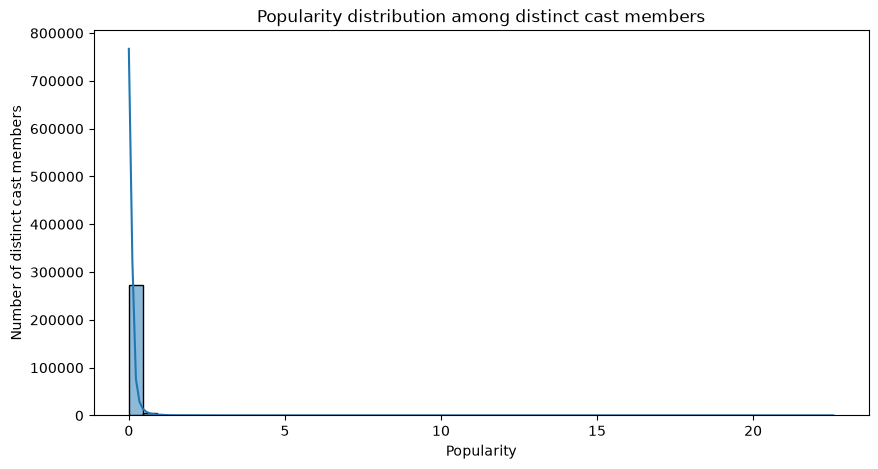

In [26]:

cast_pop_rows = []
for cast_list in cast:
    if isinstance(cast_list, list):
        for member in cast_list:
            if (
                isinstance(member, dict)
                and member.get("id") is not None
                and member.get("popularity") is not None
            ):
                cast_pop_rows.append(
                    {
                        "cast_id": member["id"],
                        "cast_name": member.get("name", ""),
                        "popularity": member["popularity"],
                    }
                )

cast_pop_df = pd.DataFrame(cast_pop_rows)

# Use the maximum observed popularity per distinct cast member as a representative value
distinct_cast_pop = (
    cast_pop_df.groupby("cast_id", as_index=False)
    .agg({"cast_name": "first", "popularity": "max"})
    .sort_values("popularity", ascending=False)
)

display(distinct_cast_pop.head(20))
print(distinct_cast_pop["popularity"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(distinct_cast_pop["popularity"], bins=50, kde=True)
plt.title("Popularity distribution among distinct cast members")
plt.xlabel("Popularity")
plt.ylabel("Number of distinct cast members")
plt.show()

In [27]:
# filter only top 10 cast members for each movie to reduce noise and focus on main actors
# or has high popularities. This is a heuristic and can be adjusted based on the dataset and requirements.

def filter_casts(cast_list, top_n=5, high_popularity_diff=10):
    """
    Filter the cast list to only include the top N members based on their order.
    If the input is not a valid list, return an empty list.
    """
    if not isinstance(cast_list, list):
        return []
    
    # Sort by 'order' and take the top N
    sorted_cast = sorted(cast_list, key=lambda x: x.get('order', float('inf')))
    top_cast = sorted_cast[:top_n]

    # If the popularity difference between the last included member and the next one is significant, include the next one as well
    if len(sorted_cast) > top_n:
        last_included = top_cast[-1]
        next_member = sorted_cast[top_n]
        
        if (
            isinstance(last_included, dict) and isinstance(next_member, dict)
            and 'popularity' in last_included and 'popularity' in next_member
        ):
            if next_member['popularity'] - last_included['popularity'] > high_popularity_diff:
                top_cast.append(next_member)
    
    # Return only the names of the top cast members
    return ["actor_"+member['name'].replace(" ", "_").lower() for member in top_cast if 'name' in member]

In [28]:
processed_cast = cast.apply(filter_casts)
processed_cast.head()

0    [actor_alec_sokolow, actor_edwin_catmull, acto...
1    [actor_jim_strain, actor_joe_johnston, actor_j...
2    [actor_howard_deutch, actor_mark_steven_johnso...
3    [actor_forest_whitaker, actor_terry_mcmillan, ...
4    [actor_alan_silvestri, actor_nancy_meyers, act...
Name: credits.crew, dtype: object

In [29]:
# Add cast crew in the df
df['cast'] = processed_cast
df['crew'] = cleaned_crew
preprocessed_columns.update(["credits.cast", "credits.crew"])
df.head()

,budget,genres,overview,production_companies,release_date,revenue,runtime,tagline,title,vote_average,vote_count,credits.cast,credits.crew,keywords.keywords,year,weighted_rating,description,keywords,crew,crew_size,cast
0,30000000,"[Family, Comedy, Animation, Adventure]","Led by Woody, Andy's toys live happily in his ...","[{'id': 3, 'logo_path': '/1TjvGVDMYsj6JBxOAkUH...",1995-11-22,401157969,81,The adventure takes off when toys come to life!,Toy Story,7.978,20023,"[{'adult': False, 'gender': 2, 'id': 31, 'know...","[{'adult': False, 'gender': 2, 'id': 12893, 'k...","[{'id': 10084, 'name': 'rescue'}, {'id': 6054,...",1995,7.974369,"Led by Woody, Andy's toys live happily in his ...","[rescue, friendship, mission, jealousy, villai...","[writer_alec_sokolow, producer_edwin_catmull, ...",208,"[actor_alec_sokolow, actor_edwin_catmull, acto..."
1,65000000,"[Adventure, Fantasy, Family]",When siblings Judy and Peter discover an encha...,"[{'id': 559, 'logo_path': '/eC0bWHVjnjUducyA6Y...",1995-12-15,262821940,104,It's a jungle in here.,Jumanji,7.247,11354,"[{'adult': False, 'gender': 2, 'id': 2157, 'kn...","[{'adult': False, 'gender': 2, 'id': 56521, 'k...","[{'id': 818, 'name': 'based on novel or book'}...",1995,7.243814,When siblings Judy and Peter discover an encha...,"[based on novel or book, giant insect, board g...","[writer_jim_strain, director_joe_johnston, pro...",136,"[actor_jim_strain, actor_joe_johnston, actor_j..."
2,25000000,"[Romance, Comedy]",A family wedding reignites the ancient feud be...,"[{'id': 19464, 'logo_path': None, 'name': 'Lan...",1995-12-22,71518503,101,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,6.478,431,"[{'adult': False, 'gender': 2, 'id': 6837, 'kn...","[{'adult': False, 'gender': 2, 'id': 26502, 'k...","[{'id': 1495, 'name': 'fishing'}, {'id': 9663,...",1995,6.482411,A family wedding reignites the ancient feud be...,"[fishing, sequel, old man, best friend, weddin...","[director_howard_deutch, writer_mark_steven_jo...",56,"[actor_howard_deutch, actor_mark_steven_johnso..."
3,16000000,"[Comedy, Drama, Romance]","Cheated on, mistreated and stepped on, the wom...","[{'id': 25, 'logo_path': '/qZCc1lty5FzX30aOCVR...",1995-12-22,81452156,127,Friends are the people who let you be yourself...,Waiting to Exhale,6.243,206,"[{'adult': False, 'gender': 1, 'id': 8851, 'kn...","[{'adult': False, 'gender': 2, 'id': 2178, 'kn...","[{'id': 818, 'name': 'based on novel or book'}...",1995,6.297186,"Cheated on, mistreated and stepped on, the wom...","[based on novel or book, single mother, divorc...","[director_forest_whitaker, writer_terry_mcmill...",33,"[actor_forest_whitaker, actor_terry_mcmillan, ..."
4,0,"[Comedy, Family]",Just when George Banks has recovered from his ...,"[{'id': 9195, 'logo_path': '/geK5QOBsXIPGHutKw...",1995-12-08,76594107,106,Just when his world is back to normal... he's ...,Father of the Bride Part II,6.273,812,"[{'adult': False, 'gender': 2, 'id': 67773, 'k...","[{'adult': False, 'gender': 2, 'id': 37, 'know...","[{'id': 5600, 'name': 'daughter'}, {'id': 1009...",1995,6.287352,Just when George Banks has recovered from his ...,"[daughter, baby, parent child relationship, mi...","[producer_nancy_meyers, writer_nancy_meyers, d...",30,"[actor_alan_silvestri, actor_nancy_meyers, act..."


In [30]:
production = df['production_companies'].apply(parse_json).apply(lambda x: ["production_" + item.lower().replace(" ", "_") for item in x if isinstance(item, str)])
production.head()
df['productions'] = production
preprocessed_columns.update(["production_companies"])

In [31]:
df.drop(list(preprocessed_columns), axis=1)

,budget,genres,revenue,runtime,title,year,weighted_rating,description,keywords,crew,cast,productions
0,30000000,"[Family, Comedy, Animation, Adventure]",401157969,81,Toy Story,1995,7.974369,"Led by Woody, Andy's toys live happily in his ...","[rescue, friendship, mission, jealousy, villai...","[writer_alec_sokolow, producer_edwin_catmull, ...","[actor_alec_sokolow, actor_edwin_catmull, acto...",[production_pixar]
1,65000000,"[Adventure, Fantasy, Family]",262821940,104,Jumanji,1995,7.243814,When siblings Judy and Peter discover an encha...,"[based on novel or book, giant insect, board g...","[writer_jim_strain, director_joe_johnston, pro...","[actor_jim_strain, actor_joe_johnston, actor_j...","[production_tristar_pictures, production_inter..."
2,25000000,"[Romance, Comedy]",71518503,101,Grumpier Old Men,1995,6.482411,A family wedding reignites the ancient feud be...,"[fishing, sequel, old man, best friend, weddin...","[director_howard_deutch, writer_mark_steven_jo...","[actor_howard_deutch, actor_mark_steven_johnso...","[production_lancaster_gate, production_warner_..."
3,16000000,"[Comedy, Drama, Romance]",81452156,127,Waiting to Exhale,1995,6.297186,"Cheated on, mistreated and stepped on, the wom...","[based on novel or book, single mother, divorc...","[director_forest_whitaker, writer_terry_mcmill...","[actor_forest_whitaker, actor_terry_mcmillan, ...",[production_20th_century_fox]
4,0,"[Comedy, Family]",76594107,106,Father of the Bride Part II,1995,6.287352,Just when George Banks has recovered from his ...,"[daughter, baby, parent child relationship, mi...","[producer_nancy_meyers, writer_nancy_meyers, d...","[actor_alan_silvestri, actor_nancy_meyers, act...","[production_touchstone_pictures, production_sa..."
...,...,...,...,...,...,...,...,...,...,...,...,...
15706,10000000,"[Comedy, Drama]",38068353,98,The Banger Sisters,2002,5.745638,"In the late '60s, the self-proclaimed belles o...","[friendship, tattoo, rock star, groupie, past,...","[director_bob_dolman, writer_bob_dolman, produ...","[actor_karl_walter_lindenlaub, actor_bob_dolma...","[production_fox_searchlight_pictures, producti..."
15707,35000000,"[Action, Adventure, Drama, Romance, War]",29882645,132,The Four Feathers,2002,6.635344,A young British officer resigns his post when ...,"[army, escape, bravery, loyalty, british empir...","[writer_michael_schiffer, writer_hossein_amini...","[actor_a.e.w._mason, actor_michael_schiffer, a...","[production_paramount_pictures, production_mir..."
15708,30000000,"[Thriller, Crime]",13414416,106,Trapped,2002,6.195109,When their daughter is abducted by experienced...,"[ransom, kidnapping, hostage, psychopath, tele...","[director_luis_mandoki, writer_greg_iles, prod...","[actor_luis_mandoki, actor_greg_iles, actor_mi...","[production_senator_film, production_propagand..."
15709,8000000,"[Comedy, Thriller, Mystery]",42400000,111,8 Women,2002,6.883085,Eight women gather to celebrate Christmas in a...,"[daughter, upper class, father murder, musical...","[writer_françois_ozon, director_françois_ozon,...","[actor_françois_ozon, actor_françois_ozon, act...","[production_fidélité_productions, production_f..."


In [32]:
if input("Type s to save") == "s":
    df.to_csv("../data/tmdb_movie_data_parsed.csv")

## Experiment on vectorizing

In [33]:
# soup = (
#     # df['cast'] + 
#     # df['crew'] + 
#     # df['keywords'] +
#     # df['description'], 
#     df['productions']
#     )
# soup = soup.apply(lambda x: " ".join([sanitize_item(item) for item in x if sanitize_item(item)]))

# # TODO: Vectorize the soup column using CountVectorizer or TfidfVectorizer for content-based recommendation system.
# vectorizer = TfidfVectorizer()
# soup_vectors = vectorizer.fit_transform(soup)
# soup_vectors.shape
# # # TODO: This might not work, it's too large

In [34]:
# Filter production companies that are too rare (e.g., appear in less than 5 movies) to reduce noise and focus on more influential production companies.
from collections import Counter
production_counter = Counter()
for production_list in df['productions']:
    if isinstance(production_list, list):
        for production in production_list:
            production_counter[production] += 1 

production_counter

Counter({'production_universal_pictures': 732,
         'production_warner_bros._pictures': 680,
         'production_paramount_pictures': 651,
         'production_columbia_pictures': 581,
         'production_20th_century_fox': 563,
         'production_metro-goldwyn-mayer': 449,
         'production_new_line_cinema': 284,
         'production_united_artists': 222,
         'production_miramax': 212,
         'production_walt_disney_pictures': 201,
         'production_touchstone_pictures': 198,
         'production_film4_productions': 194,
         'production_lionsgate': 176,
         'production_bbc_film': 159,
         'production_studiocanal': 154,
         'production_tristar_pictures': 145,
         'production_relativity_media': 132,
         'production_working_title_films': 122,
         'production_france_2_cinéma': 119,
         'production_summit_entertainment': 117,
         'production_toho': 116,
         'production_dreamworks_pictures': 116,
         'production_art

In [35]:
def normalize_production_name(prod_name):
    if not isinstance(prod_name, str):
        return prod_name

    if prod_name.startswith("production_"):
        base = prod_name[len("production_") :]
    else:
        base = prod_name

    base = base.lower()
    base = base.replace("&", " and ")
    base = re.sub(r"[^\w\s]", " ", base)
    base = re.sub(r"\s+", " ", base).strip()
    base = base.replace(" ", "_")
    base = re.sub(r"_+", "_", base).strip("_")

    # Normalize known variants
    base = re.sub(r"^warner(?:_(?:bros?|brothers?))(?:_.*)?$", "warner_bros", base)
    base = re.sub(r"^20th(?:_century)?_fox(?:_.*)?$", "20th_century_fox", base)

    return f"production_{base}"


productions_norm = df["productions"].map(
    lambda prods: [normalize_production_name(p) for p in prods]
    if isinstance(prods, list)
    else []
)

normalized_production_counts = Counter()
for prods in productions_norm:
    for p in prods:
        normalized_production_counts[p] += 1

min_production_count = 12
keep_productions = {
    prod for prod, cnt in normalized_production_counts.items() if cnt >= min_production_count
}

print(f"Keep {len(keep_productions)}, from {sum(normalized_production_counts.values())}")

productions_norm = productions_norm.map(
    lambda prods: [p for p in prods if p in keep_productions]
    if isinstance(prods, list)
    else []
)

# productions_norm.info()

production_text = productions_norm.map(" ".join)

production_vectorizer = TfidfVectorizer(
    stop_words="english",
    # preprocessor=custom_preprocessor,
    tokenizer=custom_tokenizer,
    max_features=500,
)
production_vectors = production_vectorizer.fit_transform(production_text)

production_vectors_df = pd.DataFrame(
    production_vectors.toarray(), columns=production_vectorizer.get_feature_names_out()
)
# normalized_production_counts.most_common(20), production_vectors.shape

Keep 611, from 46522


/usr/local/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'wa'] not in stop_words.
  warnings.warn(


In [36]:
print(production_vectors_df.shape)
production_vectors_df.head(5)
# TODO: Add to the main df

(15711, 500)


,production_120db_films,production_1492_pictures,production_20th_century_fox,production_20th_century_studios,production_21_laps_entertainment,production_2929_productions,production_3_arts_entertainment,production_40_acres_and_a_mule_filmworks,production_a24,production_aardman,production_alcon_entertainment,production_alcor_films,production_alliance_atlantis,production_alliance_films,production_alphaville_films,production_amazon_studios,production_amblin_entertainment,production_american_international_pictures,production_american_playhouse,production_american_zoetrope,production_annapurna_pictures,production_anonymous_content,production_anton_capital_entertainment,production_apatow_productions,production_appian_way,production_ard,production_ard_degeto,production_argos_films,production_arte,production_arte_france_cinéma,production_artisan_entertainment,production_arts_council_of_england,production_artémis_productions,production_atlas_entertainment,production_atresmedia,production_australian_film_commission,production_australian_film_finance_corporation,production_automatik_entertainment,production_auvergne_rhône_alpes_cinéma,production_avco_embassy_pictures,production_bac_films,production_bad_robot,production_baltimore_pictures,production_bandai_visual,production_bavaria_film,production_bazelevs,production_bbc,production_bbc_film,production_beacon_pictures,production_benderspink,production_bfi,production_big_beach,production_big_indie_pictures,production_big_talk_studios,production_bim_distribuzione,production_black_bear_pictures,production_blue_sky_studios,production_bluegrass_films,production_blumhouse_productions,production_bold_films,production_bona_fide_productions,production_bona_film_group,production_br,production_brightlight_pictures,production_british_screen_productions,production_broken_road_productions,production_bron_studios,production_brooksfilms,production_canal,production_canal_españa,production_capitol_films,production_caravan_pictures,production_carolco_pictures,production_castle_rock_entertainment,production_cbs_films,production_cecchi_gori_group_tiger_cinematografica,production_celluloid_dreams,production_centropolis_entertainment,production_channel_4_television,production_channel_four_films,production_chernin_entertainment,production_china_film_co_production,production_china_film_group_corporation,production_ciby_2000,production_cinergi_pictures,production_ciné,production_cj_entertainment,production_cnc,production_columbia_pictures,production_constantin_film,production_creative_wealth_media_finance,production_cross_creek_pictures,production_cruise_wagner_productions,production_ctb_film_company,production_dark_castle_entertainment,production_dark_horse_entertainment,production_david_kirschner_productions,production_davis_entertainment,production_davis_films,production_dc,production_dc_films,production_dd_productions,production_ddl_cinematografica,production_deg,production_dentsu,production_denver_and_delilah_productions,production_depth_of_field,production_destination_films,production_det_danske_filminstitut,production_detour_filmproduction,production_di_bonaventura_pictures,production_di_novi_pictures,production_diamond_docs,production_dimension_films,production_disney_channel,production_disney_television_animation,production_disneytoon_studios,production_dna_films,production_doc_society,production_don_simpson_jerry_bruckheimer_films,production_double_feature_films,production_dr,production_dreamworks_animation,production_dreamworks_pictures,production_dune_entertainment,production_dune_entertainment_iii,production_duplass_brothers_productions,production_ealing_studios,production_echo_lake_entertainment,production_eddie_murphy_productions,production_efo_films,production_el_deseo,production_element_pictures,production_emi_films,production_emmett_furla_films,production_endeavor_content,production_endgame_entertainment,production_entertainment_one,production_eon_productions,production_epsilon_motion_pictures,prod

In [37]:
# Save the preprocessed DataFrame to a new CSV file
if False: # Change to True to save the file
    df.to_csv("../data/preprocessed_movie_data.csv", index=False)

In [38]:
def whitespace_tokenizer(text):
    return text.split()

In [39]:
# Vectorize Cast
cast_vectorizer = TfidfVectorizer(
    tokenizer=whitespace_tokenizer,
    # token_pattern=r'(?u)\b\w+\b',
    max_features=3000,
)

cast_text = df['cast'].apply(lambda x: " ".join([sanitize_item(item) for item in x if sanitize_item(item)]))


cast_vector = cast_vectorizer.fit_transform(cast_text)

cast_vector.shape


/usr/local/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(15711, 3000)

In [40]:
cast_vector_df = pd.DataFrame(
    cast_vector.toarray(), columns= cast_vectorizer.get_feature_names_out()
)

cast_vector_df.head()

actor_a._kitman_ho  actor_a.i._bezzerides  actor_a.r._rahman  \
0                 0.0                    0.0                0.0   
1                 0.0                    0.0                0.0   
2                 0.0                    0.0                0.0   
3                 0.0                    0.0                0.0   
4                 0.0                    0.0                0.0   

   actor_aamir_khan  actor_aaron_rosenberg  actor_aaron_ryder  \
0               0.0                    0.0                0.0   
1               0.0                    0.0                0.0   
2               0.0                    0.0                0.0   
3               0.0                    0.0                0.0   
4               0.0                    0.0                0.0   

   actor_aaron_seltzer  actor_aaron_sorkin  actor_aaron_vexler  \
0                  0.0                 0.0                 0.0   
1                  0.0                 0.0                 0.0   
2                  0.0                 0.0                 0.0   
3                  0.0                 0.0                 0.0   
4                  0.0                 0.0                 0.0   

   actor_abbas_kiarostami  actor_abby_kohn  actor_abel_ferrara  \
0                     0.0              0.0                 0.0   
1                     0.0              0.0                 0.0   
2                     0.0              0.0                 0.0   
3                     0.0              0.0                 0.0   
4                     0.0              0.0                 0.0   

   actor_adam_fields  actor_adam_green  actor_adam_greenberg  actor_adam_herz  \
0                0.0               0.0                   0.0              0.0   
1                0.0               0.0                   0.0              0.0   
2                0.0               0.0                   0.0              0.0   
3                0.0               0.0                   0.0              0.0   
4                0.0               0.0                   0.0              0.0   

   actor_adam_kimmel  actor_adam_mckay  actor_adam_rifkin  actor_adam_sandler  \
0                0.0               0.0                0.0                 0.0   
1                0.0               0.0                0.0                 0.0   
2                0.0               0.0                0.0                 0.0   
3                0.0               0.0                0.0                 0.0   
4                0.0               0.0                0.0                 0.0   

   actor_adam_shankman  actor_adam_simon  actor_aditya_chopra  \
0                  0.0               0.0                  0.0   
1                  0.0               0.0                  0.0   
2                  0.0               0.0                  0.0   
3                  0.0               0.0                  0.0   
4                  0.0               0.0                  0.0   

   actor_adolfo_franci  actor_adolph_green  actor_adrian_biddle  \
0                  0.0                 0.0                  0.0   
1                  0.0                 0.0                  0.0   
2                  0.0                 0.0                  0.0   
3                  0.0                 0.0                  0.0   
4                  0.0                 0.0                  0.0   

   actor_adrian_lyne  actor_adrian_politowski  actor_adrienne_fazan  \
0                0.0                      0.0                   0.0   
1                0.0                      0.0                   0.0   
2                0.0                      0.0                   0.0   
3                0.0                      0.0                   0.0   
4                0.0                      0.0                   0.0   

   actor_affonso_beato  actor_affonso_gonçalves  actor_agatha_christie  \
0                  0.0                      0.0                    0.0   
1                  0.0                      0.0                    0.0  

In [41]:
list(cast_vectorizer.get_feature_names_out())

['actor_a._kitman_ho',
 'actor_a.i._bezzerides',
 'actor_a.r._rahman',
 'actor_aamir_khan',
 'actor_aaron_rosenberg',
 'actor_aaron_ryder',
 'actor_aaron_seltzer',
 'actor_aaron_sorkin',
 'actor_aaron_vexler',
 'actor_abbas_kiarostami',
 'actor_abby_kohn',
 'actor_abel_ferrara',
 'actor_adam_fields',
 'actor_adam_green',
 'actor_adam_greenberg',
 'actor_adam_herz',
 'actor_adam_kimmel',
 'actor_adam_mckay',
 'actor_adam_rifkin',
 'actor_adam_sandler',
 'actor_adam_shankman',
 'actor_adam_simon',
 'actor_aditya_chopra',
 'actor_adolfo_franci',
 'actor_adolph_green',
 'actor_adrian_biddle',
 'actor_adrian_lyne',
 'actor_adrian_politowski',
 'actor_adrienne_fazan',
 'actor_affonso_beato',
 'actor_affonso_gonçalves',
 'actor_agatha_christie',
 'actor_agnieszka_holland',
 'actor_agnès_guillemot',
 'actor_agnès_jaoui',
 'actor_agnès_varda',
 'actor_agustín_almodóvar',
 'actor_aja_frary',
 'actor_aki_kaurismäki',
 'actor_akira_ifukube',
 'actor_akira_kurosawa',
 'actor_akiva_goldsman',
 'acto

In [42]:
crew_vectorizer = TfidfVectorizer(
    tokenizer=whitespace_tokenizer,
    max_features=1500,
)

# TODO: Fix empty casts
# TODO: Fix _JR
crew_text = df['crew'].apply(lambda x: " ".join([sanitize_item(item) for item in x if sanitize_item(item)]))

crew_vector = crew_vectorizer.fit_transform(crew_text)

crew_vector.shape

crew_vector_df = pd.DataFrame(
    crew_vector.toarray(), columns=crew_vectorizer.get_feature_names_out()
)

crew_vector_df.head()

/usr/local/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


director_aki_kaurismäki  director_akira_kurosawa  director_alan_parker  \
0                      0.0                      0.0                   0.0   
1                      0.0                      0.0                   0.0   
2                      0.0                      0.0                   0.0   
3                      0.0                      0.0                   0.0   
4                      0.0                      0.0                   0.0   

   director_alex_gibney  director_alfred_hitchcock  director_ang_lee  \
0                   0.0                        0.0               0.0   
1                   0.0                        0.0               0.0   
2                   0.0                        0.0               0.0   
3                   0.0                        0.0               0.0   
4                   0.0                        0.0               0.0   

   director_antoine_fuqua  director_arthur_hiller  director_barry_levinson  \
0                     0.0                     0.0                      0.0   
1                     0.0                     0.0                      0.0   
2                     0.0                     0.0                      0.0   
3                     0.0                     0.0                      0.0   
4                     0.0                     0.0                      0.0   

   director_billy_wilder  director_blake_edwards  director_bobby_farrelly  \
0                    0.0                     0.0                      0.0   
1                    0.0                     0.0                      0.0   
2                    0.0                     0.0                      0.0   
3                    0.0                     0.0                      0.0   
4                    0.0                     0.0                      0.0   

   director_brett_ratner  director_brian_de_palma  director_bruce_beresford  \
0                    0.0                      0.0                       0.0   
1                    0.0                      0.0                       0.0   
2                    0.0                      0.0                       0.0   
3                    0.0                      0.0                       0.0   
4                    0.0                      0.0                       0.0   

   director_buster_keaton  director_charlie_chaplin  director_chris_columbus  \
0                     0.0                       0.0                      0.0   
1                     0.0                       0.0                      0.0   
2                     0.0                       0.0                      0.0   
3                     0.0                       0.0                      0.0   
4                     0.0                       0.0                      0.0   

   director_chuck_jones  director_clint_eastwood  director_curtis_hanson  \
0                   0.0                      0.0                     0.0   
1                   0.0                      0.0                     0.0   
2                   0.0                      0.0                     0.0   
3                   0.0                      0.0                     0.0   
4                   0.0                      0.0                     0.0   

   director_danny_boyle  director_dario_argento  director_david_cronenberg  \
0                   0.0                     0.0                        0.0   
1                   0.0                     0.0                        0.0   
2                   0.0                     0.0                        0.0   
3                   0.0                     0.0                        0.0   
4                   0.0                     0.0                        0.0   

   director_david_gordon_green  director_david_lynch  director_dennis_dugan  \
0                          0.0                   0.0                    0.0   
1                          0.0                   0.0                    0.0   
2                          0.0                   0.0    

In [43]:
# Vectorize description with embedding
# TODO: Sentence Transformer

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
def get_recommmendation(user_ratings, features):
    # 